In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from IPython.display import display, Image

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [8]:
from src.config import get_path

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Centralized Path Registry Resolution
DATA_P1 = get_path("data_phase1")
DATA_P3 = get_path("data_phase3")
DATA_P5 = get_path("data_phase5")
RES_P3 = get_path("results_phase3")
RES_P5 = get_path("results_phase5")

PHASE5_FIG = RES_P5 / "figures"
PHASE5_TAB = RES_P5 / "tables"
PHASE3_TAB = RES_P3 / "tables"

# Cross-venue outputs
wedge_md   = pd.read_csv(PHASE5_TAB / "matched_difference_regressions.csv")
panel_dk   = pd.read_csv(PHASE5_TAB / "panel_regressions_dk.csv")
regional   = pd.read_csv(PHASE5_TAB / "regional_mfk_summary.csv")

# Extension 1 (inverse-contract) + joint regime test
inv_wedge  = pd.read_csv(PHASE5_TAB / "inverse_contract_wedge.csv")
inv_daily  = pd.read_csv(PHASE5_TAB / "inverse_contract_daily.csv")
joint      = pd.read_csv(PHASE3_TAB / "joint_regime_test_crypto.csv")
joint_det  = pd.read_csv(PHASE3_TAB / "joint_regime_detail_crypto.csv")

> **Note on sample sizes.** Cell counts differ by data requirement, not by filtering choices: the CL20 wedge regressions require BKM extractions on both venues; the MFK requires a valid daily RND on both venues; the friction-proxy regressions additionally require CME basis and Deribit funding data. Each analysis uses the largest sample its inputs permit - the exact counts are printed by each table below and should be quoted from there.

#### 1. Cross-venue cumulant-premium wedge (matched-difference)

In [9]:
venue_wedge = wedge_md[wedge_md["regressor"] == "const (venue wedge)"].copy()
display(venue_wedge[["dep_var", "coef", "se", "t_stat", "p_value", "stars"]]
        .reset_index(drop=True))

# State interactions: confirm none significant (the wedge is a level effect)
inter = wedge_md[wedge_md["regressor"].isin(["Z_IVS_1", "rv", "fng"])]
print("State interactions (should all be insignificant -> constant level wedge):")
for dv in ["Pi_2", "Pi_3", "Pi_4"]:
    sub = inter[inter["dep_var"] == dv]
    sig = (sub["p_value"] < 0.05).any()
    print(f"  {dv}: any state interaction significant at 5%? {bool(sig)}")

,dep_var,coef,se,t_stat,p_value,stars
0,Pi_2,0.003571,0.000417,8.557052,1.157904e-17,***
1,Pi_3,0.001959,0.000573,3.419211,6.280297e-04,***
2,Pi_4,0.003264,0.001039,3.140777,1.685005e-03,***


State interactions (should all be insignificant -> constant level wedge):
  Pi_2: any state interaction significant at 5%? False
  Pi_3: any state interaction significant at 5%? False
  Pi_4: any state interaction significant at 5%? False


#### 2. Conditional / regional MFK by volatility tercile (95% bootstrap bands)

,regime,n_days,mean_down,lo_down,hi_down,mean_mid,lo_mid,hi_mid,mean_up,lo_up,hi_up
0,unconditional,619,-0.0308,-0.0417,-0.0210,0.0069,0.0045,0.0093,-0.0827,-0.1182,-0.0565
1,low,223,-0.0298,-0.0554,-0.0106,0.0024,-0.0004,0.0049,-0.1038,-0.2055,-0.0353
2,mid,191,-0.0318,-0.0458,-0.0198,0.0062,0.0046,0.0082,-0.0735,-0.0969,-0.0501
3,high,205,-0.0309,-0.0376,-0.0230,0.0124,0.0099,0.0145,-0.0682,-0.0826,-0.0481


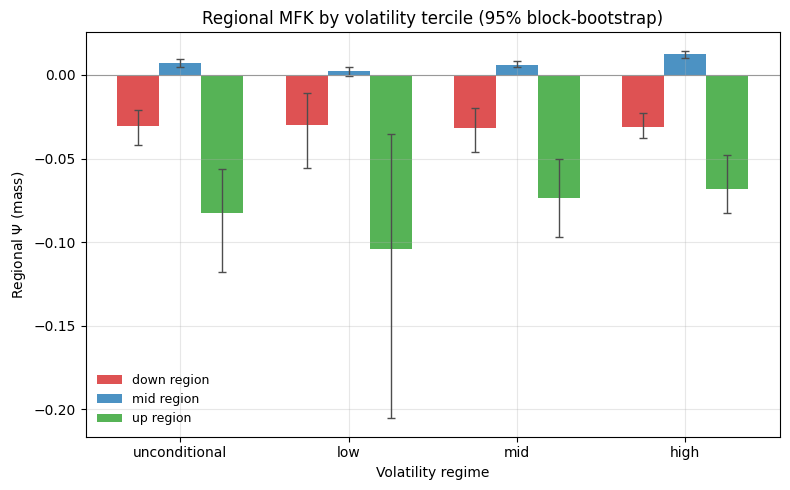

In [10]:
display(regional[["regime", "n_days", "mean_down", "lo_down", "hi_down",
                  "mean_mid", "lo_mid", "hi_mid",
                  "mean_up", "lo_up", "hi_up"]].round(4))

fig, ax = plt.subplots(figsize=(8, 5))
regimes = regional["regime"].tolist()
x = np.arange(len(regimes))
w = 0.25
for k, (reg, col) in enumerate([("down", "C3"), ("mid", "C0"), ("up", "C2")]):
    m = regional[f"mean_{reg}"].values
    lo = regional[f"lo_{reg}"].values
    hi = regional[f"hi_{reg}"].values
    ax.bar(x + (k-1)*w, m, w, color=col, alpha=0.8, label=f"{reg} region")
    ax.errorbar(x + (k-1)*w, m, yerr=[m-lo, hi-m], fmt="none",
                ecolor="0.3", capsize=3, lw=1)
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(regimes)
ax.set_ylabel(r"Regional $\Psi$ (mass)"); ax.set_xlabel("Volatility regime")
ax.set_title("Regional MFK by volatility tercile (95% block-bootstrap)")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

#### 3. Extension 1 — Inverse-contract numeraire prediction

Deribit is coin-margined (inverse) -> BTC-numeraire measure = unit Esscher tilt of the CME density. Parameter-free predicted wedge vs measured wedge. **Predicted negative, measured positive at every order: contract design predicts the wrong sign.**

,cumulant,predicted_wedge,pred_ci_lo,pred_ci_hi,measured_wedge,meas_ci_lo,meas_ci_hi,residual
0,Pi_2,-0.00367,-0.00512,-0.00230,0.00292,0.00205,0.00384,0.00659
1,Pi_3,-0.01599,-0.02068,-0.01199,0.00092,0.00053,0.00131,0.01690
2,Pi_4,-0.00374,-0.00529,-0.00222,0.00139,0.00075,0.00203,0.00513


Sign agreement: 0/3 cumulants.
Contract design predicts the WRONG sign -> the friction is real and amplified (residual > measured at every order).


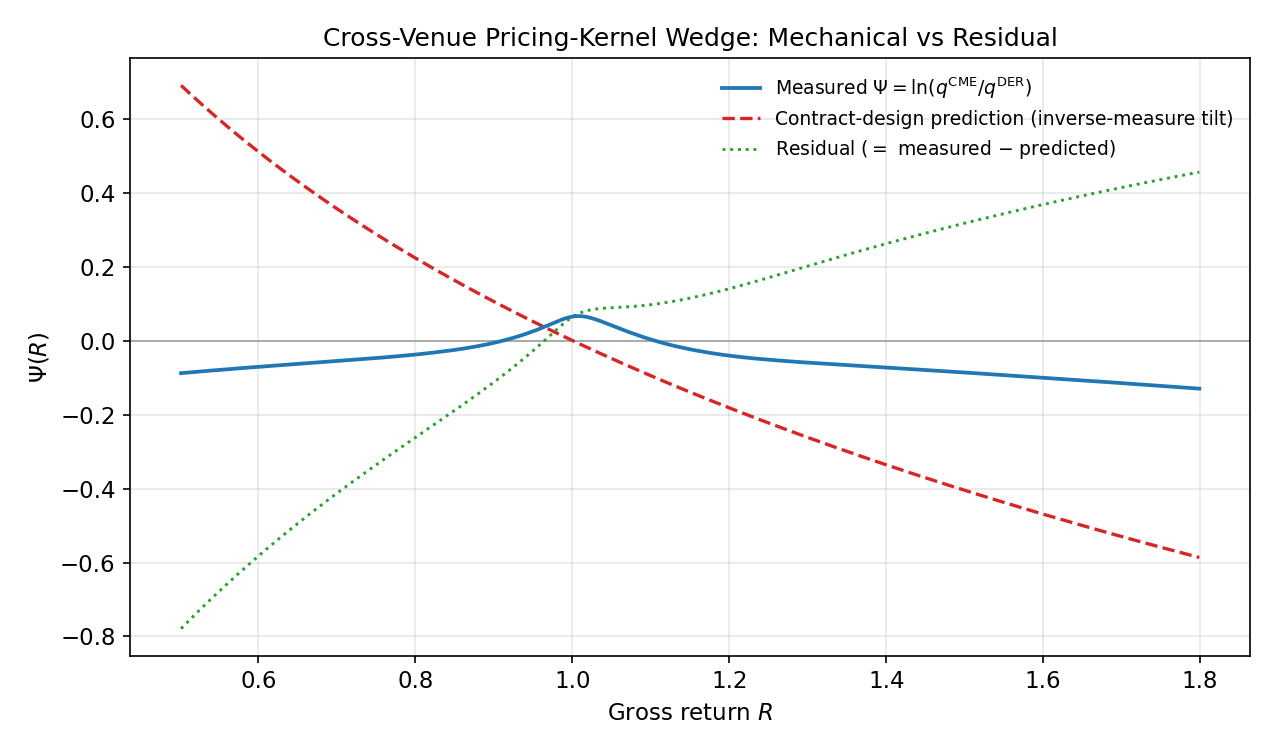

In [11]:
display(inv_wedge[["cumulant", "predicted_wedge", "pred_ci_lo", "pred_ci_hi",
                   "measured_wedge", "meas_ci_lo", "meas_ci_hi", "residual"]].round(5))

agree = int(np.sum(np.sign(inv_wedge["predicted_wedge"]) ==
                   np.sign(inv_wedge["measured_wedge"])))
print(f"Sign agreement: {agree}/{len(inv_wedge)} cumulants.")
print("Contract design predicts the WRONG sign -> the friction is real and "
      "amplified (residual > measured at every order).")

# The Psi overlay decomposition figure (mechanical vs residual)
img = PHASE5_FIG / "fig_inverse_contract_psi.png"
if img.exists():
    display(Image(filename=str(img)))
else:
    print(f"[figure not found: run run_inverse_contract.py] {img}")

#### 4. Joint regime test (Phase 3 follow-up)

The marginal curvature c is collinear (insignificant per-tercile), so the joint test of H₀: (b,c,d)_low = (b,c,d)_high is the correct question. **Significant at both venues; the low-vol kernel is more concave at the money (2c+6d).**

In [12]:
display(joint[["venue", "wald_stat", "p_value",
               "delta_b", "delta_c", "delta_d", "frac_vector_consistent"]].round(4))

curv = joint_det[joint_det["test"] == "curv_at_money_diff"]
print("Curvature at money (2c+6d at R=1), low - high:")
for _, r in curv.iterrows():
    print(f"  {r['venue']}: {r['diff_point']:+.2f} "
          f"[{r['ci_lo']:+.2f}, {r['ci_hi']:+.2f}]  P(<0) = {r['frac_negative']:.3f}")
print("\nThe kernel significantly depends on the volatility regime; the low-vol "
      "kernel is significantly more concave at the money (P<0 = 1.000 both venues).")

,venue,wald_stat,p_value,delta_b,delta_c,delta_d,frac_vector_consistent
0,CME,29.8926,0.010,15.0040,-8.9949,1.1252,0.925
1,DER,17.7239,0.025,15.4559,-9.6964,1.4163,0.970


Curvature at money (2c+6d at R=1), low - high:
  CME: -11.24 [-18.85, -7.42]  P(<0) = 1.000
  DER: -10.89 [-17.61, -6.91]  P(<0) = 1.000

The kernel significantly depends on the volatility regime; the low-vol kernel is significantly more concave at the money (P<0 = 1.000 both venues).


---
**Summary.** The cross-venue wedge is positive and significant at every cumulant
order (a constant level effect, no state interactions); contract design predicts
the opposite sign, so the friction is real and amplified; the kernel's
regime-dependence is jointly significant via the at-money curvature. The recurring
theme: cross-venue *differences* are precisely estimated where single-venue *levels*
are not.

#### 5. Regional Probability-Mass Wedge (appendix diagnostic)

The regional MFK integrates the log-density ratio; this cell reports the companion object in probability units: the difference in region mass $\int q^{CME} - \int q^{DER}$ over the downside ($R<0.90$), mid ($0.90$-$1.10$), and upside ($R>1.10$) regions, with 95% block-bootstrap bands and the same full-sample tercile stratification as the regional MFK. Positive values mean CME assigns more probability to that region.

In [15]:
# --- CELL 5: APPENDIX MASS WEDGE DIAGNOSTIC ---
import sys, warnings
from src.config import get_return_grid
from src.phase3.bootstrap_inference import (block_bootstrap_mean_bands,
                                            block_bootstrap_group_mean_bands)

R_GRID = get_return_grid()
down_m = R_GRID < 0.90
mid_m = (R_GRID >= 0.90) & (R_GRID <= 1.10)
up_m = R_GRID > 1.10

def _load_rnds(venue):
    df = pd.read_parquet(DATA_P1 / f'rnd_{venue}_densities.parquet')
    df['date'] = pd.to_datetime(df['date'])
    return df[df['tau_days'] == 27].set_index('date')

cme_d, der_d = _load_rnds('CME'), _load_rnds('DER')
matched_dates = cme_d.index.intersection(der_d.index).sort_values()

Z_crypto = pd.read_parquet(DATA_P1 / 'Z_crypto.parquet')
Z_crypto['date'] = pd.to_datetime(Z_crypto['date'])
Z_crypto['tercile'] = pd.qcut(Z_crypto['Z_IVS_1'], q=3, labels=['low', 'mid', 'high'])
terc_map = Z_crypto.set_index('date')['tercile']

def _interp(row):
    q = np.interp(R_GRID, np.array(row['returns']), np.array(row['density']),
                  left=0, right=0)
    m = np.trapezoid(q, R_GRID)
    return q / m if m > 0 else q

recs = []
for date in matched_dates:
    dq = _interp(cme_d.loc[date]) - _interp(der_d.loc[date])
    recs.append({'date': date, 'tercile': terc_map.get(date, np.nan),
                 'dm_down': np.trapezoid(dq[down_m], R_GRID[down_m]),
                 'dm_mid': np.trapezoid(dq[mid_m], R_GRID[mid_m]),
                 'dm_up': np.trapezoid(dq[up_m], R_GRID[up_m])})
mass_df = pd.DataFrame(recs).sort_values('date').reset_index(drop=True)
vals = mass_df[['dm_down', 'dm_mid', 'dm_up']].values.astype(float)
labels = mass_df['tercile'].astype(object).values

def _row(regime, band):
    return {'regime': regime, 'n_days': band['n_days'],
            'mean_down': band['mean'][0], 'lo_down': band['lo'][0], 'hi_down': band['hi'][0],
            'mean_mid': band['mean'][1], 'lo_mid': band['lo'][1], 'hi_mid': band['hi'][1],
            'mean_up': band['mean'][2], 'lo_up': band['lo'][2], 'hi_up': band['hi'][2]}

rows = [_row('unconditional', block_bootstrap_mean_bands(vals, block_length=27, B=1000, seed=42))]
g = block_bootstrap_group_mean_bands(vals, labels, ['low', 'mid', 'high'],
                                     block_length=27, B=1000, seed=42)
for terc in ['low', 'mid', 'high']:
    if terc in g:
        rows.append(_row(terc, g[terc]))
mass_wedge = pd.DataFrame(rows)
display(mass_wedge.round(4))
mass_wedge.to_csv(PHASE5_TAB / 'regional_mass_wedge_summary.csv', index=False)
print(f"Sign: positive = CME assigns more mass to the region ({len(mass_df)} matched days).")

,regime,n_days,mean_down,lo_down,hi_down,mean_mid,lo_mid,hi_mid,mean_up,lo_up,hi_up
0,unconditional,619,-0.0096,-0.0124,-0.0066,0.0185,0.0132,0.0236,-0.0089,-0.0112,-0.0063
1,low,223,-0.0055,-0.0099,-0.0001,0.0111,-0.0001,0.0199,-0.0055,-0.0099,0.0003
2,mid,191,-0.0095,-0.0126,-0.0064,0.0185,0.0138,0.0242,-0.0090,-0.0122,-0.0062
3,high,205,-0.0141,-0.0171,-0.0104,0.0266,0.0216,0.0312,-0.0125,-0.0149,-0.0099


Sign: positive = CME assigns more mass to the region (619 matched days).
